# US Firm Characteristics: Feasibility Analysis

This notebook tests whether the Chen-Pelger-Zhu (2020) anonymized firm-
characteristics panel can deliver on the strategy declared in
`config/setup.yaml`. `setup.yaml` is the canonical, hand-curated source of
truth: universe rules, costs, decision cadence, mapping class, labels, sweep
grid, evaluation protocol. This notebook does not write it. Instead, it
produces the evidence that justifies its values: cross-sectional breadth over
time, monthly return distributions relative to era-dependent transaction
costs, a walk-forward fold demonstration, and a return-to-cost scale ratio. Findings
persist to `config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (breadth, identity, holdout)
- Document the provider's point-in-time update conventions
- Compare monthly return scale with the declared transaction-cost range
- Demonstrate the operational walk-forward structure has adequate breadth per fold
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2--6.6

## Prerequisites

- Firm characteristics data available via `load_firm_characteristics()`
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""US Firm Characteristics: Feasibility Analysis."""

import json
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.ticker import PercentFormatter

from data import load_firm_characteristics
from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, add_message_title

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
START_DATE = "1990-01-01"
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("us_firm_characteristics")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
# Chen-Pelger-Zhu (2020) dataset coverage; restrict to post-1990 for modern
# market structure. Dataset ends Dec 2016; holdout is the final year.
END_DATE = "2016-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])

# Era boundary: decimalization (NYSE/AMEX 2001-01-29; NASDAQ 2001-04-09).
DECIMALIZATION_DATE = "2001-01-29"

---

## Section A: Orientation (Section 6.2)

Firm characteristics (fundamentals) are the canonical input for cross-sectional
asset pricing in the academic literature (Fama-French, Hou-Xue-Zhang,
Gu-Kelly-Xiu, Chen-Pelger-Zhu). The CPZ (2020) panel is **fully anonymized**:
identifiers are anonymous but persistent within each released tensor block.
Returns are monthly. The provider updates annual characteristics at the end
of June and monthly characteristics at month-end for use in the next month.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Is cross-sectional breadth adequate for the largest top-k grid?
- **Costs**: How does monthly return scale compare with transaction costs
  (15--30 bps RT pre-decimalization, 5--15 bps RT post)?
- **Evaluation**: Do 10 annual walk-forward folds each carry enough cross-
  sectional breadth?
- **Holdout**: Is the holdout (2016) cleanly separated from training data?

**Dominant frictions** for this case study:
- **Point-in-time discipline**: Provider update conventions are assumed because
  the release does not expose source filing or market-data vintages.
- **Short-side capacity**: Long-short requires borrow (the short leg targets
  growth stocks, which can be hard to borrow).
- **Universe anonymization**: The release includes only complete 46-feature
  observations and does not expose the original CRSP identifiers.
- **Illiquidity concentration risk**: ML can select from the smallest, widest-
  spread stocks (Avramov, Cheng, and Metzker 2020); realistic small-cap costs
  are 100--500 bps, not the 5--20 bps assumed for liquid names.

---

## Section B: Universe and Cost Feasibility (Sections 6.3--6.4)

### B.1 Load and Explore the Data

In [4]:
firm_chars = load_firm_characteristics(split="all")

start_dt = pl.lit(START_DATE).str.to_date()
end_dt = pl.lit(END_DATE).str.to_date()
firm_chars = firm_chars.filter((pl.col("timestamp") >= start_dt) & (pl.col("timestamp") <= end_dt))

n_dates = firm_chars["timestamp"].n_unique()
n_rows = len(firm_chars)
avg_stocks_per_month = n_rows // max(n_dates, 1)

print(
    f"Loaded firm characteristics: ~{avg_stocks_per_month:,} stocks/month, {n_dates} monthly dates"
)
print(f"  Period: {firm_chars['timestamp'].min()} to {firm_chars['timestamp'].max()}")
print(f"  Total rows: {n_rows:,}")
print(f"  Persistent anonymous firms in active split: {firm_chars['symbol'].n_unique():,}")

Loaded firm characteristics: ~2,483 stocks/month, 324 monthly dates
  Period: 1990-01-31 to 2016-12-30
  Total rows: 804,530
  Persistent anonymous firms in active split: 9,861


**Note on identifiers**: the authors' NPZ tensors retain a fixed anonymous firm
axis within each train, validation, and test block. The canonical converter
preserves that axis as `symbol` and namespaces the blocks because the archive
does not publish a cross-block mapping. All operational folds and the 2016
holdout lie within the 1992-2016 test block, where identity is persistent.

### B.2 Cross-Sectional Breadth Over Time

Monthly cross-sectional breadth is critical for this case study because
top-k sorts require sufficient firms per cross-section. We need at least
100 stocks to fill the largest declared long-short configuration (50 per leg).
The CPZ release keeps complete cases across all 46 characteristics, so breadth
here is the complete-case count rather than a verified liquidity universe.

In [5]:
breadth = firm_chars.group_by("timestamp").agg(pl.len().alias("n_stocks")).sort("timestamp")

print("Cross-sectional breadth (monthly):")
print(f"  Min stocks/month:  {breadth['n_stocks'].min():,}")
print(f"  Max stocks/month:  {breadth['n_stocks'].max():,}")
print(f"  Mean stocks/month: {breadth['n_stocks'].mean():,.0f}")
print(f"  Months: {len(breadth)}")

Cross-sectional breadth (monthly):
  Min stocks/month:  1,933
  Max stocks/month:  2,826
  Mean stocks/month: 2,483
  Months: 324


#### Visualize Breadth Over Time

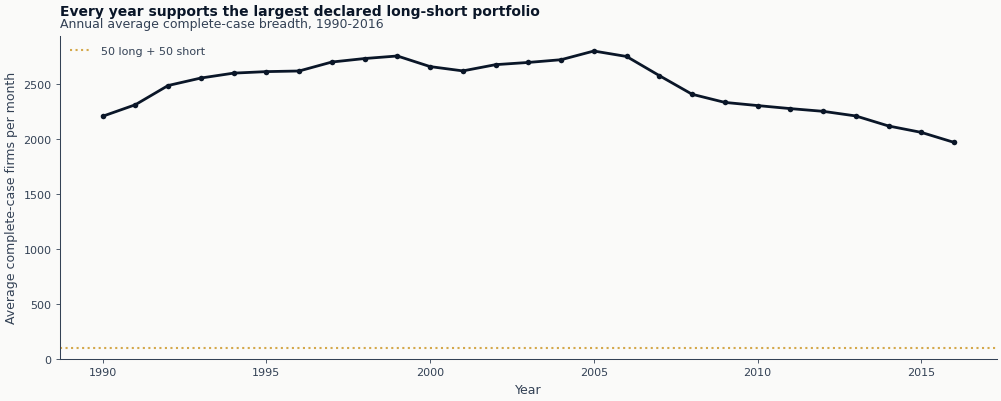

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
years = breadth.with_columns(pl.col("timestamp").dt.year().alias("year"))
annual = years.group_by("year").agg(pl.col("n_stocks").mean()).sort("year")
ax.plot(
    annual["year"].to_numpy(),
    annual["n_stocks"].to_numpy(),
    "o-",
    color=COLORS["blue"],
    linewidth=2,
)
ax.axhline(
    100,
    color=COLORS["amber"],
    linestyle=":",
    linewidth=1.5,
    label="50 long + 50 short",
)
ax.set_xlabel("Year")
ax.set_ylabel("Average complete-case firms per month")
add_message_title(
    ax,
    "Every year supports the largest declared long-short portfolio",
    "Annual average complete-case breadth, 1990-2016",
)
ax.legend(loc="upper left")
ax.set_ylim(0, None)
fig.show()

**Characteristic coverage**: the released panel is already a complete-case
sample, so each retained row carries all 46 firm characteristics. The check
below verifies that parser and filtering behavior preserve that contract.

In [7]:
char_cols = [c for c in firm_chars.columns if c not in ("ret", "timestamp", "symbol", "split")]
coverage = firm_chars.select([pl.col(c).is_not_null().mean().alias(c) for c in char_cols]).row(
    0, named=True
)
mean_coverage = float(np.mean(list(coverage.values())))
low_coverage = {k: v for k, v in coverage.items() if v < 0.8}

print(f"Characteristic coverage ({len(char_cols)} characteristics):")
print(f"  Mean coverage: {mean_coverage:.1%}")
if low_coverage:
    print(f"  Below 80% coverage ({len(low_coverage)}):")
    for k, v in sorted(low_coverage.items(), key=lambda x: x[1]):
        print(f"    {k}: {v:.1%}")
else:
    print("  All characteristics above 80% coverage")

Characteristic coverage (46 characteristics):
  Mean coverage: 100.0%
  All characteristics above 80% coverage


### B.3 Trading Cost Analysis: Era-Dependent Horizon Feasibility

`setup.yaml::costs` declares an era-dependent cost model:

- **Pre-decimalization (before 2001-01-29)**: 15--30 bps per leg (30--60 bps RT).
  Tick size of $1/16$ ($0.0625$) widened spreads; commissions were ~3--5 cents/share.
- **Post-decimalization (2001-01-29 onward)**: 5--15 bps per leg (10--30 bps RT).
  Penny tick regime; electronic trading collapsed spreads.

A long-short overlay further requires borrow on the short leg (~50 bps/yr).

**Key question**: do typical monthly equity moves exceed costs in each era?

In [8]:
# Pre / post decimalization cost midpoints
PRE_RT_COST = 0.0045  # 45 bps mid (pre-decimal RT range 30-60 bps)
POST_RT_COST = 0.0020  # 20 bps mid (post-decimal RT range 10-30 bps)
POOLED_RT_COST = POST_RT_COST  # primary feasibility uses post-decimal (sample-dominant era)
ROUND_TRIP_COST_BPS = int(POST_RT_COST * 10_000)

decimalization_dt = pl.lit(DECIMALIZATION_DATE).str.to_date()
holdout_start_dt = pl.lit(HOLDOUT_START).str.to_date()

monthly_returns = firm_chars.filter(
    pl.col("ret").is_not_null() & (pl.col("timestamp") < holdout_start_dt)
).select(["timestamp", "ret"])
monthly_rets_arr = monthly_returns["ret"].to_numpy()
abs_rets = np.abs(monthly_rets_arr)
print(f"Monthly returns (pre-holdout, non-null): {len(monthly_rets_arr):,} stock-months")

Monthly returns (pre-holdout, non-null): 780,882 stock-months


#### Summary Statistics by Era

Split absolute monthly returns into pre- and post-decimalization buckets to
show how the return-to-cost scale changes by era.

In [9]:
pre_mask = monthly_returns["timestamp"].to_numpy() < np.datetime64(DECIMALIZATION_DATE)
post_mask = ~pre_mask

pre_abs = abs_rets[pre_mask]
post_abs = abs_rets[post_mask]


def era_stats(data: np.ndarray, label: str, rt_cost: float) -> dict:
    """Cost-exceedance statistics for one era."""
    return {
        "era": label,
        "n_stock_months": int(len(data)),
        "median_pct": float(np.median(data) * 100),
        "mean_pct": float(np.mean(data) * 100),
        "p75_pct": float(np.percentile(data, 75) * 100),
        "p95_pct": float(np.percentile(data, 95) * 100),
        "pct_above_rt_cost": float((data > rt_cost).mean() * 100),
        "rt_cost_bps": float(rt_cost * 10_000),
    }


era_df = pl.DataFrame(
    [
        era_stats(pre_abs, "Pre-decimal (1990 -- 2001-01-28)", PRE_RT_COST),
        era_stats(post_abs, "Post-decimal (2001-01-29 onward)", POST_RT_COST),
    ]
)
era_df.select(
    [
        "era",
        "n_stock_months",
        pl.col("median_pct").round(2).alias("median %"),
        pl.col("mean_pct").round(2).alias("mean %"),
        pl.col("p75_pct").round(2).alias("p75 %"),
        pl.col("p95_pct").round(2).alias("p95 %"),
        pl.col("rt_cost_bps").alias("RT cost (bps)"),
        pl.col("pct_above_rt_cost").round(1).alias("% > cost"),
    ]
)

era,n_stock_months,median %,mean %,p75 %,p95 %,RT cost (bps),% > cost
str,i64,f64,f64,f64,f64,f64,f64
"""Pre-decimal (1990 -- 2001-01-2…",339015,7.45,11.19,14.49,33.36,45.0,94.7
"""Post-decimal (2001-01-29 onwar…",441867,6.78,10.22,13.1,30.82,20.0,98.1


**Fraction of monthly moves exceeding cost threshold** (pooled across the sample):

In [10]:
COST_THRESHOLDS_BPS = [10, 20, 30, 40, 60]
pooled_row = {"horizon": "Monthly"}
for cost_bps in COST_THRESHOLDS_BPS:
    pooled_row[f"{cost_bps}_bps"] = float((abs_rets > cost_bps / 10_000).mean() * 100)
cost_df = pl.DataFrame([pooled_row])
cost_df.select(
    [
        "horizon",
        pl.col("10_bps").round(1).alias("10 bps %"),
        pl.col("20_bps").round(1).alias("20 bps %"),
        pl.col("30_bps").round(1).alias("30 bps %"),
        pl.col("40_bps").round(1).alias("40 bps %"),
        pl.col("60_bps").round(1).alias("60 bps %"),
    ]
)

horizon,10 bps %,20 bps %,30 bps %,40 bps %,60 bps %
str,f64,f64,f64,f64,f64
"""Monthly""",99.2,98.5,97.4,96.1,93.7


#### Visualize the Monthly Return Distribution

Cost reference lines at 20 bps (post-decimal mid) and 60 bps (pre-decimal upper
bound, before borrow) show the cost-exceedance margin.

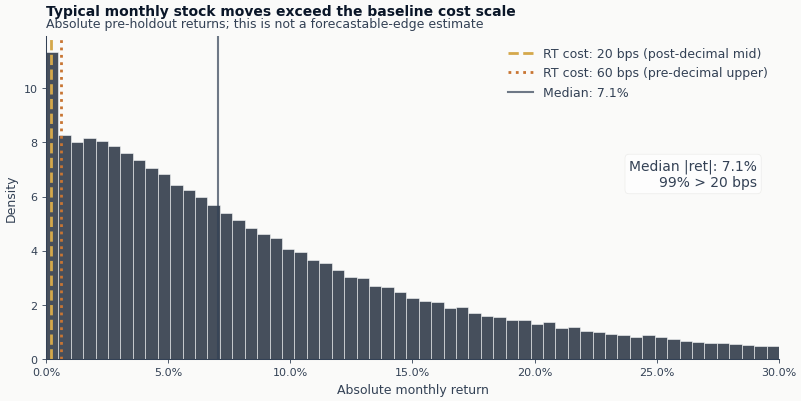

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
xlim = 0.30  # clip far tail
clipped = abs_rets[abs_rets < xlim]
bins = np.linspace(0, xlim, 60)
ax.hist(
    clipped,
    bins=bins,
    density=True,
    alpha=0.75,
    color=COLORS["blue"],
    edgecolor="white",
)

for bps, ls, lbl in [
    (20, "--", "RT cost: 20 bps (post-decimal mid)"),
    (60, ":", "RT cost: 60 bps (pre-decimal upper)"),
]:
    ax.axvline(
        bps / 10_000,
        color=COLORS["amber" if bps == 20 else "copper"],
        linestyle=ls,
        linewidth=2,
        label=lbl,
    )

median_val = float(np.median(abs_rets))
ax.axvline(
    median_val,
    color=COLORS["neutral"],
    linestyle="-",
    linewidth=1.5,
    alpha=0.7,
    label=f"Median: {median_val * 100:.1f}%",
)

frac_above_20 = float((abs_rets > 0.0020).mean())
ax.text(
    0.97,
    0.62,
    f"Median |ret|: {median_val * 100:.1f}%\n{frac_above_20:.0%} > 20 bps",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("Absolute monthly return")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
add_message_title(
    ax,
    "Typical monthly stock moves exceed the baseline cost scale",
    "Absolute pre-holdout returns; this is not a forecastable-edge estimate",
)
ax.set_xlim(0, xlim)
ax.legend(loc="upper right", fontsize=9)
fig.show()

#### Interpretation

Monthly return dispersion is large relative to the declared cost range, so the
data has enough cross-sectional movement for ranking research. This comparison
does not show that any predictable edge survives costs. That requires the
turnover-aware net backtests in notebooks 11-14.

### B.4 Return-to-Cost Scale Ratio (Primary Label Horizon)

The primary label is `fwd_ret_1m` (monthly; `setup.yaml::labels.primary`). The
scale diagnostic compares the typical realized move with the post-decimal
round-trip cost. It is not a strategy edge-to-cost ratio.

In [12]:
median_monthly_abs = float(np.median(abs_rets))
return_cost_scale_ratio = median_monthly_abs / POOLED_RT_COST
print(f"Median monthly |return|: {median_monthly_abs:.4f} ({median_monthly_abs * 10_000:.0f} bps)")
print(f"Post-decimal RT cost: {POOLED_RT_COST:.4f} ({POOLED_RT_COST * 10_000:.0f} bps)")
print(f"Monthly return-to-cost scale ratio: {return_cost_scale_ratio:.0f}x")
print("Assessment: dispersion is sufficient; strategy feasibility remains untested")

Median monthly |return|: 0.0706 (706 bps)
Post-decimal RT cost: 0.0020 (20 bps)
Monthly return-to-cost scale ratio: 35x
Assessment: dispersion is sufficient; strategy feasibility remains untested


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml`. They are
justified here in prose; the YAML is the canonical, hand-curated source of truth.

### C.1 Decision Cadence

`setup.yaml::decision.cadence: monthly_month_end` --- snapshot at month-end
close, execute at the next bar open (`execution_delay: next_bar_open`). Monthly
is the conventional cadence for cross-sectional firm-characteristics studies
(Fama and French 1993; Hou, Xue, and Zhang 2015; Gu, Kelly, and Xiu 2020;
Chen, Pelger, and Zhu 2022), which makes results directly comparable to
published benchmarks.

**Why monthly is the natural choice here**:

- The CPZ dataset *is* monthly; the `ret` column is the realized return over
  month $t$ given characteristics available for the prediction. Decision-cadence
  thinning is automatic; there is no sub-monthly grid to thin from.
- The provider updates annual characteristics at the end of June; rebalancing
  more frequently than monthly adds no new information from those variables.
- Long-short turnover at monthly cadence is manageable; weekly rebalancing
  would amplify rank-flip noise without a faster underlying signal.
- The provider updates annual variables at the end of June and monthly variables
  at month-end for the next month. The release does not expose source vintages,
  so this notebook documents that convention rather than claiming a uniform lag.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints --- if any triggers, the strategy
is abandoned or substantially reworked. Defining them upfront prevents post-hoc
rationalization. The thresholds below are anchored to the feasibility evidence
above and to the firm-characteristics literature:

- **KC1 (IC floor)**: no single factor (value, profitability, momentum) achieves
  cross-sectional IC > 0.01 with HAC t-stat > 2.0. Gate: Chapter 8 feature
  evaluation. The 46-characteristic universe gives ample exploratory breadth;
  if nothing clears this bar, the cross-sectional anomaly literature is not
  replicable on this sample.
- **KC2 (edge-cost)**: net performance fails after realistic transaction costs
  and borrow. Gate: notebooks 11-14. Section B.4 is only a return-scale check;
  it does not pre-clear this kill condition.
- **KC3 (incremental IC)**: all factor premia disappear after controlling for
  size and momentum (no incremental IC from fundamentals). Gate: Chapter 8
  factor decomposition.
- **KC4 (illiquidity concentration)**: long or short leg holds >50% in the
  least-liquid quintile by the released size, turnover, and spread proxies.
  Gate: notebooks 13 and 15.

### C.3 Mapping Class

`setup.yaml::mapping.class: long_short_top_k_rebalance`:
`position_state_space: long_short`,
`entry_logic: rank_top_k_long_bottom_k_short`,
`sizing: equal_weight_within_leg`. The reasoning:

- **Long-short** is the canonical mapping for cross-sectional firm-
  characteristics anomalies because the bottom-ranked tail can carry
  negative-expected-return information (small-cap effects with the sign
  flipped, distressed firms, etc.). Long-only would discard this signal. Borrow
  is generally available for the mid- and large-cap subset most cross-sectional
  strategies touch at ~50 bps/yr (encoded in `costs.borrow_cost_note`).
- **Top-k sort** follows the declared grid of 5, 10, 20, and 50 names per leg.
  The largest portfolio uses about 4% of the average monthly cross-section and
  5.2% in the narrowest month.
- **Equal-weight within each leg** is the minimal-assumption sizing rule; it
  avoids introducing a secondary optimization (value-weighting, risk-parity,
  inverse-vol) that would confound evaluation of the ranking signal itself.
  Notebook 12 compares equal weighting with score and conformal weighting.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify the data supports the walk-forward design declared in
`setup.yaml::evaluation`: 10 splits, a 10-year train window, a 1-year
validation window,
`holdout_start=2016-01-01`, `holdout_end=2016-12-31`.

### D.1 Effective Sample Size and Data Coverage

In [13]:
pre_holdout = firm_chars.filter(pl.col("timestamp") < holdout_start_dt)
n_decision_dates = pre_holdout["timestamp"].n_unique()
first_month = firm_chars["timestamp"].min()
last_month = firm_chars["timestamp"].max()
n_years = n_decision_dates / 12

print("Data Coverage:")
print(f"  Period: {first_month} to {last_month}")
print(f"  Pre-holdout decision points (months): {n_decision_dates}")
print(f"  Approx pre-holdout years: {n_years:.1f}")
print(f"  Holdout: {HOLDOUT_START} to {SETUP['evaluation']['holdout_end']}")

Data Coverage:
  Period: 1990-01-31 to 2016-12-30
  Pre-holdout decision points (months): 312
  Approx pre-holdout years: 26.0
  Holdout: 2016-01-01 to 2016-12-31


### D.2 Walk-Forward Fold Demonstration

`utils.cv_splits.generate_cv_splits` owns the operational split construction.
This cell calls that utility directly rather than maintaining a second manual
implementation. Each fold has:

- **Train period**: 10 years
- **Validation period**: 1 year
- **Purge gap**: 1 month between train end and test start (matches the 1M
  buffer for the monthly primary label)

Folds are generated backward from the sealed 2016 holdout. The one-month label
buffer leaves 11 observed monthly validation points per fold, for 110 common
validation months in total.

In [14]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
splits = generate_cv_splits(
    firm_chars.select("timestamp"),
    setup_path=CASE_DIR / "config" / "setup.yaml",
    label_buffer=str(SETUP["labels"]["buffer"]),
)

print(f"Generated {len(splits)} walk-forward folds")

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_validation_end = max(split["val_end"] for split in splits)
print(f"Last validation end: {last_validation_end.date()}  |  Holdout start: {HOLDOUT_START}")
assert last_validation_end.date() < datetime.fromisoformat(HOLDOUT_START).date(), (
    f"Last fold ({last_validation_end.date()}) overlaps holdout ({HOLDOUT_START})"
)

Generated 10 walk-forward folds
Last validation end: 2015-12-31  |  Holdout start: 2016-01-01


**Walk-forward fold summary:**

In [15]:
splits_df = pl.DataFrame(splits).with_columns(
    pl.col("train_start", "train_end", "val_start", "val_end").cast(pl.Date)
)
splits_df

fold,train_start,train_end,val_start,val_end
i64,date,date,date,date
0,2005-03-31,2014-12-31,2015-02-27,2015-12-31
1,2004-04-30,2014-02-28,2014-03-31,2015-01-30
2,2003-05-30,2013-03-28,2013-04-30,2014-02-28
3,2002-06-28,2012-04-30,2012-05-31,2013-03-28
4,2001-07-31,2011-04-29,2011-06-30,2012-04-30
5,2000-08-31,2010-05-28,2010-07-30,2011-05-31
6,1999-09-30,2009-07-31,2009-08-31,2010-06-30
7,1998-10-30,2008-08-29,2008-09-30,2009-07-31
8,1997-11-28,2007-09-28,2007-10-31,2008-08-29


#### Universe Breadth per Fold

We verify each validation window has adequate cross-sectional breadth for the
largest declared top-k portfolio.

In [16]:
fold_breadth = []
for split in splits:
    validation = firm_chars.filter(
        pl.col("timestamp").is_between(split["val_start"], split["val_end"], closed="both")
    )
    n_avg = int(validation.height // max(validation["timestamp"].n_unique(), 1))
    fold_breadth.append(
        {
            "fold": split["fold"],
            "validation_start": split["val_start"].date(),
            "validation_end": split["val_end"].date(),
            "avg_n_stocks": n_avg,
        }
    )

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Average complete-case firms per validation month:")
fold_breadth_df

Average complete-case firms per validation month:


fold,validation_start,validation_end,avg_n_stocks
i64,date,date,i64
0,2015-02-27,2015-12-31,2058
1,2014-03-31,2015-01-30,2112
2,2013-04-30,2014-02-28,2190
3,2012-05-31,2013-03-28,2250
4,2011-06-30,2012-04-30,2260
5,2010-07-30,2011-05-31,2298
6,2009-08-31,2010-06-30,2320
7,2008-09-30,2009-07-31,2348
8,2007-10-31,2008-08-29,2444


Breadth is comfortable in every fold (well over 1,000 names), supporting the
largest declared configuration of 50 firms per leg.

---

## Section E: Derived Artifacts

The CPZ panel is a complete-case academic release, not a reader-configurable
eligibility universe. There is no separate eligibility table to materialize.
The only artifact this notebook persists is the feasibility report (Section F).

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. Setup.yaml is not regenerated here --- it is the hand-curated
source of truth, and this notebook reads it.

In [17]:
n_stocks_min = int(min(fb["avg_n_stocks"] for fb in fold_breadth))
n_stocks_max = int(max(fb["avg_n_stocks"] for fb in fold_breadth))
n_folds_generated = int(len(splits))

median_pre_pct = float(np.median(pre_abs) * 100)
median_post_pct = float(np.median(post_abs) * 100)
median_all_pct = float(np.median(abs_rets) * 100)
frac_above_20bps = float((abs_rets > 0.0020).mean())
frac_above_60bps = float((abs_rets > 0.0060).mean())

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.inclusion_rule = {SETUP['universe']['inclusion_rule']}")
print(f"  -> avg stocks per month (pre-holdout panel): {avg_stocks_per_month:,}")
print(f"  -> firms per validation window: min={n_stocks_min:,}, max={n_stocks_max:,}")
print("  -> all operational folds use persistent IDs from the released test tensor")

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |monthly return| = {median_all_pct:.2f}%; "
    f"{frac_above_20bps * 100:.0f}% exceed 20bps RT"
)

print()
print(f"decision.characteristic_availability = {SETUP['decision']['characteristic_availability']}")
print(
    f"  -> annual updates: {SETUP['decision']['yearly_update']}; "
    f"monthly updates: {SETUP['decision']['monthly_update']}"
)

print()
print(f"costs.class = {SETUP['costs']['class']} (era-dependent)")
print(
    f"  -> pre-decimal era: median |ret| = {median_pre_pct:.2f}% "
    f"vs {PRE_RT_COST * 10_000:.0f} bps RT mid"
)
print(
    f"  -> post-decimal era: median |ret| = {median_post_pct:.2f}% "
    f"vs {POST_RT_COST * 10_000:.0f} bps RT mid"
)
print(f"  -> monthly return-to-cost scale @ 20bps RT: {return_cost_scale_ratio:.0f}x")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(
    f"  -> median |1m return| = {median_all_pct:.2f}% "
    f"= {return_cost_scale_ratio:.0f}x a 20bps cost scale"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print("  -> fwd_ret_1m_win: winsorized return tail; fwd_class_1m: directional label")

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(
    f"  -> validation spans {min(split['val_start'] for split in splits).date()} "
    f"to {last_validation_end.date()}; "
    f"holdout {SETUP['evaluation']['holdout_start']} "
    f"to {SETUP['evaluation']['holdout_end']}"
)

print()
print(f"mapping.class = {SETUP['mapping']['class']} ({SETUP['mapping']['position_state_space']})")
print(f"  -> {n_stocks_min:,}+ firms/month supports 50 names per long and short leg")

Setup.yaml knobs vs feasibility evidence

universe.inclusion_rule = complete_characteristic_case
  -> avg stocks per month (pre-holdout panel): 2,483
  -> firms per validation window: min=2,058, max=2,625
  -> all operational folds use persistent IDs from the released test tensor

decision.cadence = monthly_month_end
  -> median |monthly return| = 7.06%; 99% exceed 20bps RT

decision.characteristic_availability = provider_standard_conventions
  -> annual updates: end_of_june; monthly updates: month_end_for_next_month

costs.class = material (era-dependent)
  -> pre-decimal era: median |ret| = 7.45% vs 45 bps RT mid
  -> post-decimal era: median |ret| = 6.78% vs 20 bps RT mid
  -> monthly return-to-cost scale @ 20bps RT: 35x

labels.primary = fwd_ret_1m
  -> median |1m return| = 7.06% = 35x a 20bps cost scale

labels.variants = ['fwd_ret_1m_win', 'fwd_class_1m']
  -> fwd_ret_1m_win: winsorized return tail; fwd_class_1m: directional label

evaluation.n_splits = 10
  -> generated 10 folds

### Persist Feasibility Findings

In [18]:
feasibility_report = {
    "case_study_id": CASE_STUDY_ID,
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "avg_stocks_per_month": int(avg_stocks_per_month),
        "n_months": int(n_dates),
        "min_stocks_per_month": int(breadth["n_stocks"].min()),
        "max_stocks_per_month": int(breadth["n_stocks"].max()),
        "n_stocks_per_fold_min": n_stocks_min,
        "n_stocks_per_fold_max": n_stocks_max,
        "characteristic_coverage_mean": mean_coverage,
        "low_coverage_count": int(len(low_coverage)),
        "identity_scope": SETUP["universe"]["identifiers"],
    },
    "return_distribution_abs_pct": {
        "median_pre_decimal": median_pre_pct,
        "median_post_decimal": median_post_pct,
        "median_pooled": median_all_pct,
    },
    "cost_exceedance_pct": {
        "above_20bps": frac_above_20bps * 100,
        "above_60bps": frac_above_60bps * 100,
    },
    "era_dependent_costs": {
        "decimalization_date": DECIMALIZATION_DATE,
        "pre_decimal_rt_bps_mid": PRE_RT_COST * 10_000,
        "post_decimal_rt_bps_mid": POST_RT_COST * 10_000,
        "horizon_table": era_df.to_dicts(),
    },
    "return_to_cost_scale_ratio_monthly_at_20bps": float(return_cost_scale_ratio),
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "validation_start": str(min(split["val_start"] for split in splits).date()),
        "validation_end": str(last_validation_end.date()),
        "holdout_start": HOLDOUT_START,
        "holdout_end": str(SETUP["evaluation"]["holdout_end"]),
        "label_buffer": str(SETUP["labels"]["buffer"]),
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2, default=str)
print(f"Written: {display_path(report_path)}")

Written: output/us_firm_signoff_20260721/us_firm_characteristics/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe and identity**: The CPZ release keeps complete cases across all
   46 characteristics. The canonical converter recovers persistent anonymous
   identifiers within each released tensor block. Every operational fold and
   the holdout use the same 1992-2016 identity namespace.
2. **Cost scale**: Typical monthly moves exceed the 20-60 bps cost range, but
   realized return magnitude is not predictable edge. Net feasibility remains
   a turnover-aware backtest question for notebooks 11-14.
3. **Cadence**: Monthly month-end is the canonical cross-sectional firm-
   characteristics cadence (Fama-French, Hou-Xue-Zhang, Gu-Kelly-Xiu,
   Chen-Pelger-Zhu). It aligns mechanically with the CPZ data structure and
   with the provider's annual-June and monthly-next-month update conventions.
4. **Mapping**: Long-short top-k equal-weight as baseline; alternative
   allocators sweep via `setup.yaml::backtest.sweep.allocators` (explored in
   Chapter 17).
5. **Evaluation**: 10 backward-generated walk-forward folds contribute 110
   validation months from November 2006 through December 2015, followed by the
   sealed 2016 holdout. The 1M label buffer separates every train/validation pair.
6. **Kill conditions**: no strategy kill condition is pre-cleared by raw return
   dispersion. IC, net cost survival, and liquidity concentration are tested
   downstream.

**Known limitations**:
- **Dataset ends December 2016**: holdout covers only 2016 (12 months). The
  "death of value" post-2018 cannot be tested here.
- **Anonymized identifiers**: identities cannot be linked across the three
  released tensor blocks or back to CRSP; survivorship handling cannot be
  audited from the public release alone.
- **Long-short borrow**: 50 bps/yr is a flat assumption; in practice borrow
  varies sharply by name and time, especially for hard-to-borrow growth names.
- **Small-cap costs**: 20 bps RT is a liquid-name midpoint; ML can select firms
  with adverse size, turnover, and spread proxies where realistic costs are much
  higher. Notebooks 13 and 15 stress this exposure.

**Artifacts written**:
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: [`02_labels`](02_labels.ipynb) creates `fwd_ret_1m`, `fwd_ret_1m_win`,
and `fwd_class_1m` per `setup.yaml::labels`.